<a href="https://colab.research.google.com/github/raghavkarthikcse2025-coder/daa-lab/blob/main/Exp-2%20with%20outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

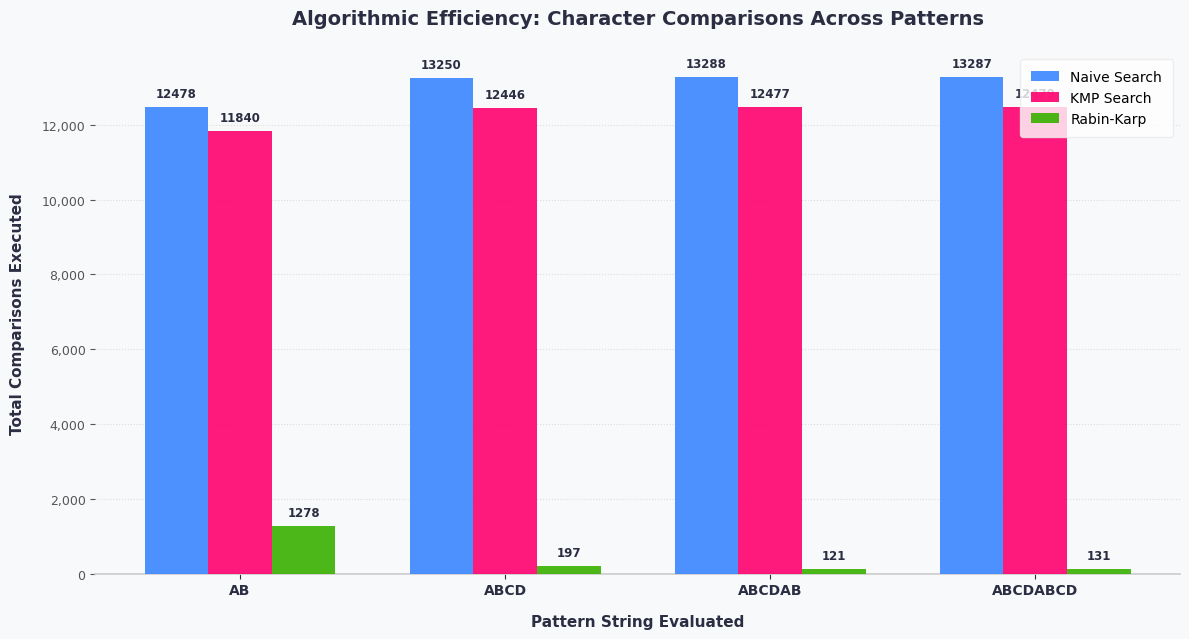

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Simplified Search Algorithms ---

def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comps = 0
    for i in range(n - m + 1):
        for j in range(m):
            comps += 1
            if text[i + j] != pattern[j]:
                break
    return comps

def compute_lps(pattern):
    lps = [0] * len(pattern)
    length, i = 0, 1
    while i < len(pattern):
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        elif length:
            length = lps[length - 1]
        else:
            i += 1
    return lps

def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)
    comps, i, j = 0, 0, 0

    while i < n:
        comps += 1
        if pattern[j] == text[i]:
            i, j = i + 1, j + 1
            if j == m:
                j = lps[j - 1]
        elif j:
            j = lps[j - 1]
        else:
            i += 1
    return comps

def rabin_karp(text, pattern, q=101):
    n, m = len(text), len(pattern)
    d, h = 256, pow(256, m - 1, q)
    p_hash = t_hash = comps = 0

    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q

    for s in range(n - m + 1):
        if p_hash == t_hash:
            for k in range(m):
                comps += 1
                if text[s + k] != pattern[k]:
                    break
        if s < n - m:
            t_hash = (d * (t_hash - ord(text[s]) * h) + ord(text[s + m])) % q
            if t_hash < 0:
                t_hash += q
    return comps

# --- Benchmarking Setup ---
text_large = ''.join(random.choices('ABCD', k=10000))
patterns = ['AB', 'ABCD', 'ABCDAB', 'ABCDABCD']

algorithms = {
    'Naive Search': naive_search,
    'KMP Search': kmp_search,
    'Rabin-Karp': rabin_karp
}

results = {name: [search_fn(text_large, p) for p in patterns] for name, search_fn in algorithms.items()}

# --- Ultra-Polished Visual Plotting ---
x = np.arange(len(patterns))
width = 0.24  # Reduced slightly to add a clean gap between grouped pattern categories

# Set up a sleek figure style
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=100)
fig.patch.set_facecolor('#F8F9FA')  # Light neutral off-white background
ax.set_facecolor('#F8F9FA')

# Vibrant, modern professional color palette
colors = {
    'Naive Search': '#3A86FF',  # Electric Blue
    'KMP Search': '#FF006E',    # Neon Pink
    'Rabin-Karp': '#38B000'     # Vivid Green
}

# Plot bars and dynamically inject value labels above them
for i, (name, data) in enumerate(results.items()):
    offset = (i - 1) * width
    rects = ax.bar(
        x + offset, data, width,
        label=name, color=colors[name],
        edgecolor='none', alpha=0.9, zorder=3
    )
    # Add exact numeric labels above bars so you don't have to squint at the axis
    ax.bar_label(rects, padding=5, fontsize=8.5, fontweight='bold', color='#2B2D42')

# Styling & Layout Fine-tuning
ax.set_title('Algorithmic Efficiency: Character Comparisons Across Patterns',
             fontsize=14, fontweight='bold', pad=20, color='#2B2D42')
ax.set_xlabel('Pattern String Evaluated', fontsize=11, fontweight='semibold', labelpad=12, color='#2B2D42')
ax.set_ylabel('Total Comparisons Executed', fontsize=11, fontweight='semibold', labelpad=12, color='#2B2D42')

ax.set_xticks(x)
ax.set_xticklabels(patterns, fontsize=10, fontweight='semibold')

# Clean up the chart boundaries (Minimalist theme - remove top, right, and left spines)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['bottom'].set_linewidth(1.2)

# Format y-axis ticks with commas (e.g., 10,000 instead of 10000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val):,}'))
ax.tick_params(axis='y', colors='#555555', labelsize=9)
ax.tick_params(axis='x', colors='#2B2D42')

# Soft horizontal gridlines placed behind the bars
ax.grid(axis='y', linestyle=':', linewidth=0.8, color='#DDDDDD', zorder=0)

# Modern legend placement
ax.legend(
    frameon=True, facecolor='#FFFFFF', edgecolor='#EAEAEA',
    shadow=False, loc='upper right', fontsize=10, borderpad=0.8
)

plt.tight_layout()
plt.show()